# 📌 Pretraining

In [3]:
import os
import sys

REPO_URL = 'https://github.com/lucasqueiros/hpc.git'

%cd /content

if os.path.exists('hpc'):
    !rm -rf hpc

!git clone {REPO_URL}
%cd hpc

UTILS_PATH = '/content/hpc/llm-lab/utils/matteus'

if UTILS_PATH not in sys.path:
    sys.path.append(UTILS_PATH)

/content
Cloning into 'hpc'...
remote: Enumerating objects: 190, done.
remote: Counting objects: 100% (190/190), done.
remote: Compressing objects: 100% (138/138), done.
remote: Total 190 (delta 67), reused 124 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (190/190), 16.80 MiB | 19.44 MiB/s, done.
Resolving deltas: 100% (67/67), done.
/content/hpc


- Generating text and calculating the cross-entropy loss

In [4]:
from utils_llm import generate_text_simple, GPT_CONFIG_124M, GPTModel
import torch

model = GPTModel(GPT_CONFIG_124M)
model.eval();

In [5]:
import tiktoken

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'[EOS]'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

In [6]:
start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=5,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you Provided Dev Plum rap imaginative


In [7]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

In [8]:
with torch.no_grad():
    logits = model(inputs)

print(logits.shape)

torch.Size([2, 3, 50257])


In [9]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()

In [10]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
loss

tensor(10.9624)

Compute training and validation cross-entropy loss for GPTModel on the Frankenstein dataset.

In [11]:
import requests
url = "https://www.gutenberg.org/files/84/84-0.txt"

def load_frankenstein():
    response = requests.get(url)
    response.raise_for_status()
    return response.text

text = load_frankenstein()

In [12]:
total_characters = len(text)
total_tokens = len(tokenizer.encode(text))

print(f"Characters: {total_characters}")
print(f"tokens: {total_tokens}")

Characters: 419434
tokens: 101747


In [13]:
from utils_llm import create_dataloader_v1

train_ratio = 0.90
split_index = int(train_ratio * len(text))
train_data = text[:split_index]
val_data = text[split_index:]

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [14]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 91136
Validation tokens: 9984
All tokens: 101120


In [15]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [16]:
device = torch.device("cuda")
model.to(device);

In [18]:
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 11.008106263835778
Validation loss: 11.003592538833619


In [17]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(57662.6094)


# 📌 GPT Model Training

In [19]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()

In [20]:
generate_and_print_sample(model=model, tokenizer=tokenizer, device=device, start_context="the king of")

the king of legalityearned coun Editors transl pupilsNDmarkatiowings Nest punch Zarraw GMaturation Canyon Lub675iveryanie Gentle paraceaeStorage Training lanesilver Camera Bananamage fluorescent perception breat weldLabor Keys Testing 175 right undeniably PET android211497riend impart Goals Olympics=-=-=-=-=-=-=-=-


In [21]:
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
    start_context="the king of", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.776, Val loss 9.733
Ep 1 (Step 000050): Train loss 6.524, Val loss 6.727
Ep 1 (Step 000100): Train loss 5.985, Val loss 6.302
Ep 1 (Step 000150): Train loss 5.951, Val loss 6.134
the king of the                                            I, and, and
Ep 2 (Step 000200): Train loss 5.886, Val loss 6.091
Ep 2 (Step 000250): Train loss 5.604, Val loss 5.997
Ep 2 (Step 000300): Train loss 5.627, Val loss 5.976
Ep 2 (Step 000350): Train loss 5.418, Val loss 5.952
the king of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the 
Ep 3 (Step 000400): Train loss 5.264, Val loss 5.978
Ep 3 (Step 000450): Train loss 5.121, Val loss 5.961
Ep 3 (Step 000500): Train loss 5.007, Val loss 5.893
the king of the          and I was a and a few minutes, and I was a  and I was a and a  and the and a the  the  and I
Ep 4 (Step 000550): Train loss 4.985, Val loss 5.917
Ep 4 (Step 000600): Train loss 4.813, Val loss

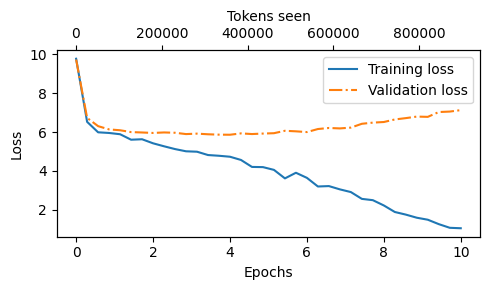

In [23]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [22]:
generate_and_print_sample(model=model, tokenizer=tokenizer, device=device, start_context="the king of")

the king of the building, which beneficence.   “When Felix seemed to Perth, and across Montal—places. I arrived. This part of the merchant had left in caves dispersed themselves at the talking to the Safie,


## Decoding strategies

In [24]:
inference_device = "cpu"
model.to(inference_device)
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("the king of", tokenizer).to(inference_device),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 the king of the building, which
beneficence.


“When Felix seemed to Perth, and across Montal—


In [25]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # New (not in book): numerical stability tip to get equivalent results on mps device
            # subtract rowwise max before softmax
            logits = logits - logits.max(dim=-1, keepdim=True).values

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered and eos_id is specified
            break

        # Same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

In [26]:
token_ids = generate(
    model=model,
    idx=text_to_token_ids("the king of", tokenizer).to(inference_device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 the king of her evils. She was called some days by the species, for the presence
